<a href="https://colab.research.google.com/github/OlhaZahrebelna/python_for_ds_task/blob/main/Zahrebelna_Olha_%22HW_2_4_kNN_%D0%9A%D1%80%D0%BE%D1%81%D0%B2%D0%B0%D0%BB%D1%96%D0%B4%D0%B0%D1%86%D1%96%D1%8F_%D1%96_%D1%82%D1%8E%D0%BD%D0%B8%D0%BD%D0%B3_%D0%B3%D1%96%D0%BF%D0%B5%D1%80%D0%BF%D0%B0%D1%80%D0%B0%D0%BC%D0%B5%D1%82%D1%80%D1%96%D0%B2_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

0. Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
import time

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [4]:
import importlib.util

path = "/content/drive/MyDrive/Competition/process_bank_churn.py"
spec = importlib.util.spec_from_file_location("process_bank_churn", path)
mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)

# перевірка
print("Loaded:", mod)
print("Functions:", [x for x in dir(mod) if not x.startswith("_")][:20])

Loaded: <module 'process_bank_churn' from '/content/drive/MyDrive/Competition/process_bank_churn.py'>
Functions: ['Any', 'Dict', 'List', 'OneHotEncoder', 'Optional', 'Pipeline', 'Sequence', 'SimpleImputer', 'StandardScaler', 'Tuple', 'annotations', 'build_numeric_pipeline', 'build_onehot_encoder', 'create_inputs_targets', 'fit_transform_categorical', 'fit_transform_numeric', 'get_numeric_categorical_cols', 'np', 'pd', 'preprocess_data']


In [5]:
preprocess_data = mod.preprocess_data

1. Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

In [6]:
raw_df = pd.read_csv('/content/drive/MyDrive/Competition/train.csv')
X_train, y_train, X_val, y_val, input_cols, num_pipe, encoder = preprocess_data(raw_df)

In [7]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [8]:
train_preds = knn.predict_proba(X_train)[:, 1]
val_preds = knn.predict_proba(X_val)[:, 1]

train_auc = roc_auc_score(y_train, train_preds)
val_auc = roc_auc_score(y_val, val_preds)

print("Train AUC:", train_auc)
print("Val AUC:", val_auc)

Train AUC: 0.9591523765053621
Val AUC: 0.869003054900934


Модель демонструє ознаки перенавчання (overfitting), оскільки значення AUROC на тренувальній вибірці (0.96) суттєво перевищує значення на валідаційній (0.87). Це свідчить про високу варіативність моделі (high variance).

2. Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [9]:
param_grid = {
    "n_neighbors": [5, 11, 21, 31],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

In [10]:
grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5, #5 фолдів
    scoring="roc_auc",
    n_jobs=-1
)

grid.fit(X_train, y_train)

knn_best = grid.best_estimator_

print("Best k:", grid.best_params_)

Best k: {'metric': 'manhattan', 'n_neighbors': 31, 'weights': 'distance'}


In [11]:
train_preds = knn_best.predict_proba(X_train)[:, 1]
val_preds = knn_best.predict_proba(X_val)[:, 1]

print("Train AUC:", roc_auc_score(y_train, train_preds))
print("Val AUC:", roc_auc_score(y_val, val_preds))

Train AUC: 1.0
Val AUC: 0.9134740333420617


В цьому випадку ми теж бачимо, що модельперенавчається. Але дані на валідаційних данних краще, ніж в першому завданні.

3. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

In [12]:
param_grid = {
    "max_depth": list(range(1, 21, 2)),
    "max_leaf_nodes": list(range(2, 11))
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

grid.fit(X_train, y_train)

dt_best = grid.best_estimator_

print("Best params:", grid.best_params_)

Best params: {'max_depth': 5, 'max_leaf_nodes': 10}


In [13]:
train_preds_dt = dt_best.predict_proba(X_train)[:, 1]
val_preds_dt = dt_best.predict_proba(X_val)[:, 1]

print("Train AUC dt:", roc_auc_score(y_train, train_preds_dt))
print("Val AUC dt:", roc_auc_score(y_val, val_preds_dt))

Train AUC dt: 0.9036642716685185
Val AUC dt: 0.8997720171074451


Знайшли оптимальні параметри для дереваприйняття рішень. Це глубина 5 та максимальна кількість кінцевих відповідей 10

4. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
    - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
    - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

In [14]:
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

In [15]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [16]:
dt_random_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=params_dt,
    n_iter=40,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

t0 = time.perf_counter()
dt_random_search.fit(X_train, y_train)
t1 = time.perf_counter()

print(f"Search time: {t1 - t0:.2f} sec")
print("Best params (RandomizedSearchCV):", dt_random_search.best_params_)

dt_random_search_best = dt_random_search.best_estimator_

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Search time: 2.02 sec
Best params (RandomizedSearchCV): {'splitter': 'best', 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_leaf_nodes': np.int64(14), 'max_features': None, 'max_depth': np.int64(16), 'criterion': 'entropy'}


In [17]:
train_pred = dt_random_search_best.predict_proba(X_train)[:, 1]
val_pred   = dt_random_search_best.predict_proba(X_val)[:, 1]

train_auc = roc_auc_score(y_train, train_pred)
val_auc   = roc_auc_score(y_val, val_pred)

print("Train AUC (Random):", train_auc)
print("Val AUC (Random):", val_auc)

Train AUC (Random): 0.9148290433524566
Val AUC (Random): 0.9118034389456227


5. Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

In [18]:
test_path = "/content/drive/MyDrive/Competition/test.csv"
test_df = pd.read_csv(test_path)

X_test = mod.preprocess_new_data(
    new_df=test_df,
    input_cols=input_cols,
    scaler=num_pipe,
    encoder=encoder
)

test_proba = knn_best.predict_proba(X_test)[:, 1]

In [19]:
sample_path = "/content/drive/MyDrive/Competition/sample_submission.csv"
sample_sub = pd.read_csv(sample_path)
sample_sub["Exited"] = test_proba
sample_sub.to_csv("submission_knn_best.csv", index=False)

Random Tree

In [20]:
test_proba_dt = dt_random_search_best.predict_proba(X_test)[:, 1]

In [21]:
sample_sub["Exited"] = test_proba_dt

out_path = "/content/drive/MyDrive/Competition/submission_dt_random.csv"
sample_sub.to_csv(out_path, index=False)

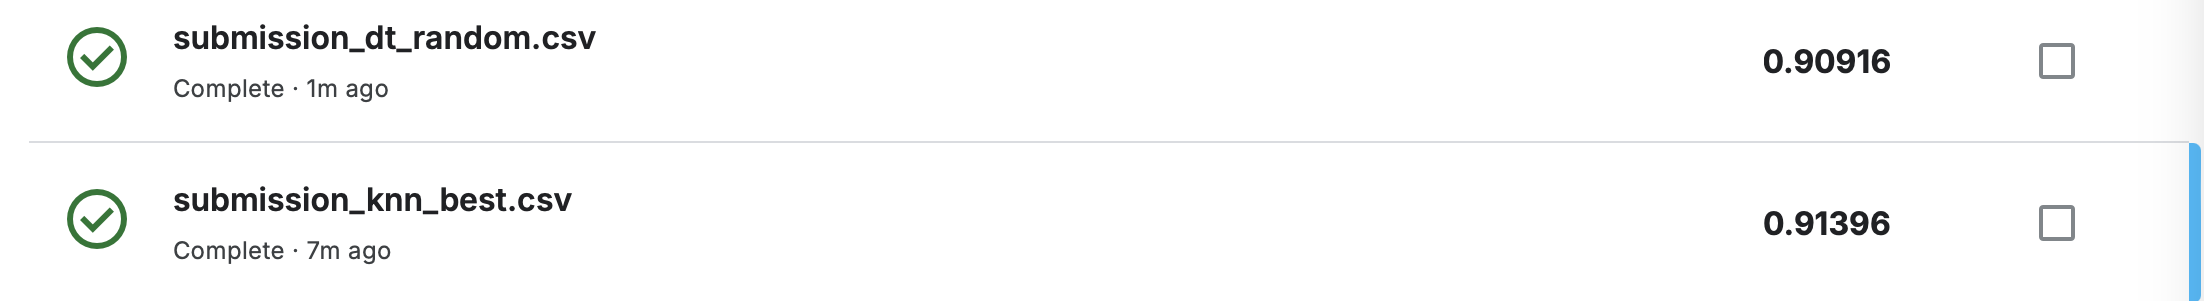

Найвищу якість на валідаційній вибірці показала модель KNN (AUROC ≈ 0.913), однак вона демонструє ознаки перенавчання, оскільки значення на тренувальній вибірці дорівнює 1.0, що значно перевищує результат на валідації.
Моделі Decision Tree (особливо після RandomizedSearchCV) показали дещо нижчу якість (AUROC ≈ 0.912), але при цьому мають значно менший розрив між train і validation, що свідчить про кращу узагальнюючу здатність.
Таким чином, KNN забезпечує найкращу точність, але схильна до перенавчання, тоді як Decision Tree є більш стабільною моделлю.